## Conditional Sequence with LSTM
* 목표 : Condition Data, Label Data를 함께 입력하여 학습한 후에 조건만 사용하여 Label과 유사한 시퀀스 데이터 생성
* Condition Data는 한개의 시퀀스 내에서 동일하게 설정한다면 LSTM에 의해 학습되지 않음
* Condition Data는 한개의 시퀀스 내에서 동일하므로 변화의 패턴을 학습하는 LSTM에서는 학습이 안됨
* Condition Data는 학습 과정에서 계산 과정에서는 사용됨
* 아래의 코드에서는 Conditional Sequence 모델을 생성/학습/모델 저장/학습된 모델을 사용하여 Landmark를 생성함
* Blender에서 생성된 mp4 비디오로부터 추출된 Landamrk를 학습하고 학숩 후에는 Armature의 각도를 이용하여 Landmark를 생성함
* 학습된 모델의 predict()를 호출할 때는 Condition Data와 Label Data를 함께 입력해야 함(학습할 때의 형식 준수)
* model.predict()를 호출할 때는 Condition Data는 임의의 값이면 되고, Label Data는 크기(학습시의 형식)만 갖춘 더미 데이터이면 된다
* random seed에 따른 학습 성과 확인, 걷기(9), 달리기(43)

### 데이터 전처리
* Conditional Sequence 모델을 생성하기 위해서 필요한 데이터(Condition, Label)를 준비함
* Blender에서 렌더링한 mp4 비디오에서 추출된 Landamrk(csv)를 전처리하여 조건 데이터와 Label 데이터 파일 생성
* Blender 비디오에서 추출된 Landmark가 저정된 경로 : C:/test/landmarks-csv/run/
* 위의 경로에 저장된 파일명에서 각도를 추출하여 별도의 조건 데이터 파일에 저장 : C:/test/anim_run_conditions.csv

In [37]:
# 캐릭터의 회전각도를 조건으로 입력 받고 해당 캐릭터의 Landmark를 Label로 입력 받아 그 관계성이 학습됨
# csv 파일명에서 회전각도(deg)를 추출하여 파일명과 함께 조건 파일(anim-condition.csv)에 저장한다
# 저장할 때의 컬럼명은 "fname", "deg" 으로 지정함
import os
import csv
import re

# 대상 디렉토리
directory = "C:/test/landmarks-csv/run/"             # 모든 landmark를 포함한 csv 파일 저장 경로
output_file = "C:/test/anim_run_conditions.csv"      # csv 파일명에 포함된 Armature 회전각도를 추출하여 저장할 파일경로

# 결과를 저장할 리스트
results = []

# 정규 표현식으로 각도를 추출 (예: 파일명이 "animation_angle_-1_qw_..."인 경우 -1 추출)
angle_pattern = re.compile(r'_angle_(-?\d+)_')

# 디렉토리 내 파일 순회
for filename in os.listdir(directory):
    if filename.endswith(".csv"):
        match = angle_pattern.search(filename)
        if match:
            angle = match.group(1)
            results.append({"fname": filename, "deg": angle})

# 결과를 CSV 파일에 저장
with open(output_file, "w", newline="", encoding="utf-8") as csvfile:
    fieldnames = ["fname", "deg"]
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    writer.writeheader()
    for result in results:
        writer.writerow(result)

print(f"총 {len(results)}개의 파일에서 각도를 추출했습니다. 결과는 '{output_file}'에 저장되었습니다.")


총 181개의 파일에서 각도를 추출했습니다. 결과는 'C:/test/anim_run_conditions.csv'에 저장되었습니다.


### 재현 가능한 코드를 작성하기 위해 SEED 값을 설정하는 함수

In [38]:
import tensorflow as tf
import random
import numpy as np

def set_seed(seed=43):                         # walk일 때는 9로 확인됨, run은 34
    random.seed(seed)                         # Python random 모듈 시드 설정
    np.random.seed(seed)                      # NumPy 시드 설정
    tf.random.set_seed(seed)                  # TensorFlow 시드 설정

### Conditional Sequence 모델을 정의/학습/모델저장/학습된 모델을 사용하여 Landmark 생성

72/72 [==============================] - 1s 9ms/step - loss: 2.6638e-05 - mae: 0.0036 - val_loss: 8.3765e-06 - val_mae: 0.0019
Epoch 911/1000
72/72 [==============================] - 1s 8ms/step - loss: 2.6135e-05 - mae: 0.0036 - val_loss: 9.1064e-06 - val_mae: 0.0020
Epoch 912/1000
72/72 [==============================] - 1s 9ms/step - loss: 2.6530e-05 - mae: 0.0036 - val_loss: 8.3653e-06 - val_mae: 0.0019
Epoch 913/1000
72/72 [==============================] - 1s 9ms/step - loss: 2.6039e-05 - mae: 0.0036 - val_loss: 1.0612e-05 - val_mae: 0.0021
Epoch 914/1000
72/72 [==============================] - 1s 9ms/step - loss: 2.6225e-05 - mae: 0.0036 - val_loss: 7.8072e-06 - val_mae: 0.0018
Epoch 915/1000
72/72 [==============================] - 1s 8ms/step - loss: 2.6143e-05 - mae: 0.0036 - val_loss: 8.4330e-06 - val_mae: 0.0019
Epoch 916/1000
72/72 [==============================] - 1s 8ms/step - loss: 2.7009e-05 - mae: 0.0037 - val_loss: 8.9421e-06 - val_mae: 0.0020
Epoch 917/1000
72/72 

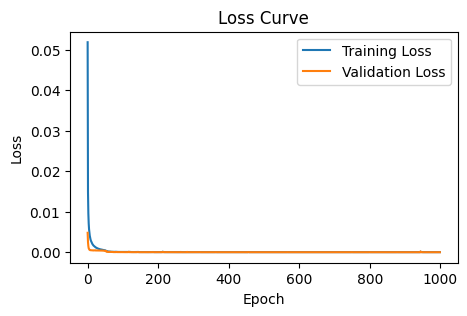

최종 학습된 모델이 c:/test/models/conditional_run_LSTM_model.keras에 저장되었습니다.
2/2 [==============================] - 0s 6ms/step


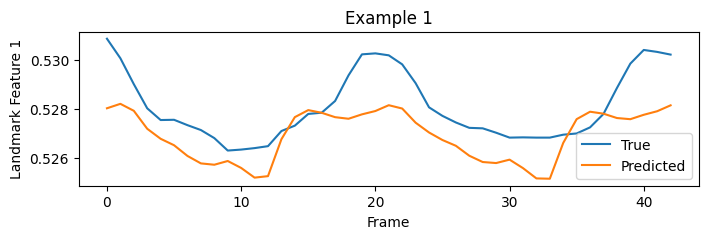

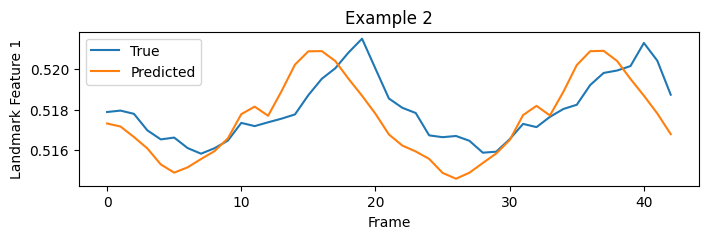

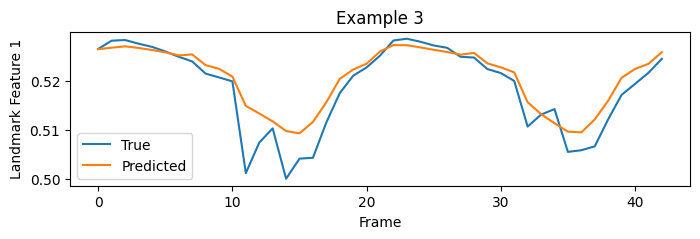

저장된 모델을 성공적으로 로드했습니다.
2/2 [==============================] - 0s 6ms/step


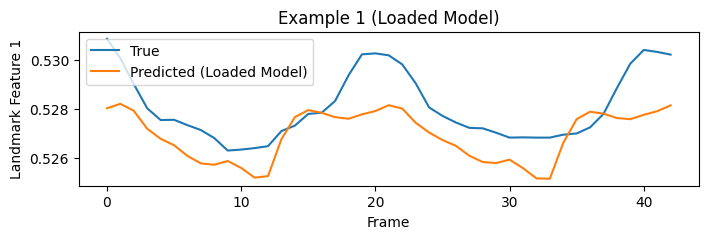

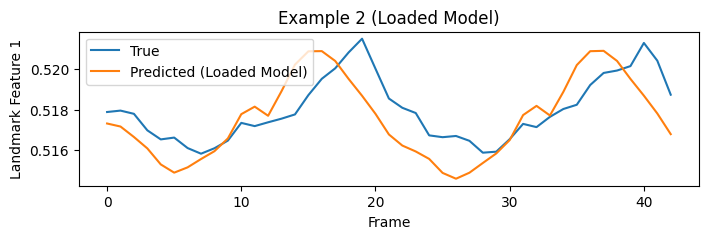

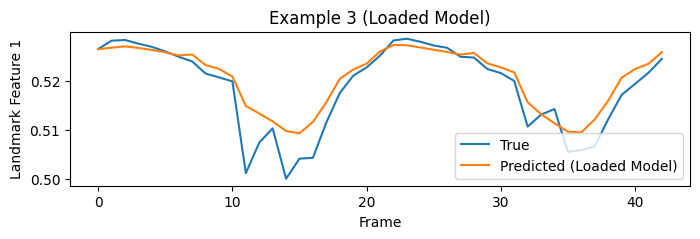

저장된 모델을 성공적으로 로드했습니다.
2/2 [==============================] - 0s 6ms/step


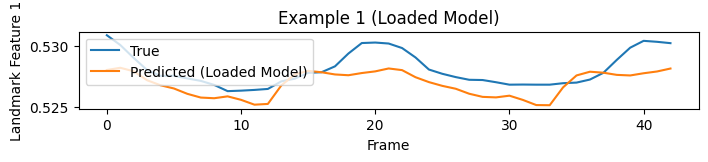

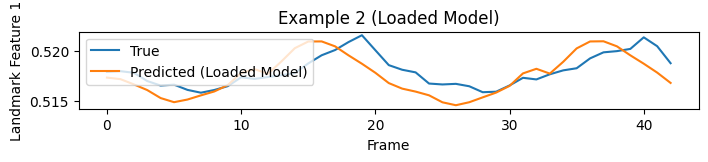

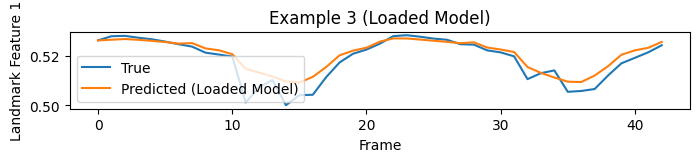

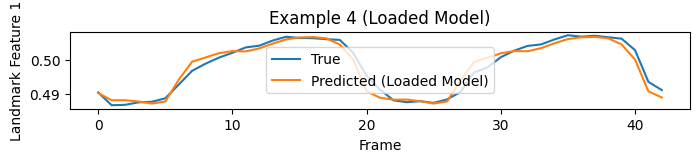

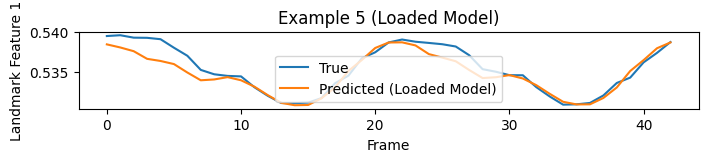

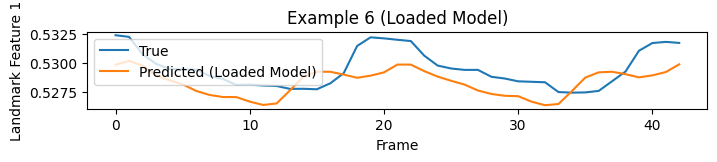

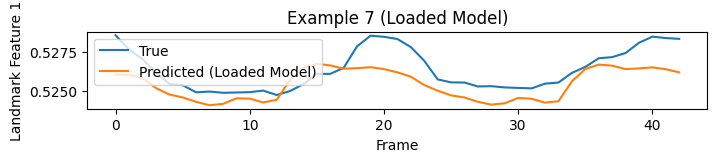

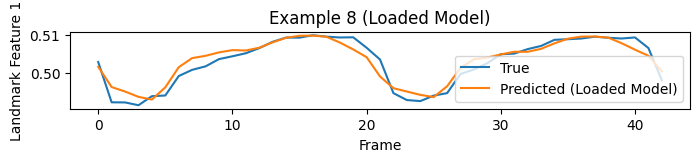

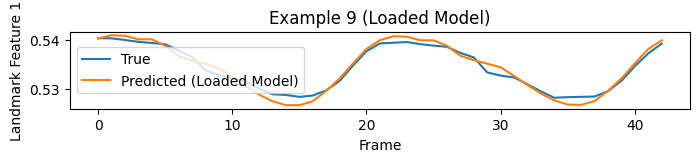

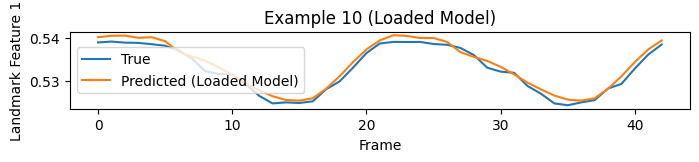

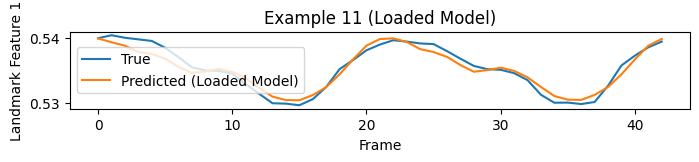

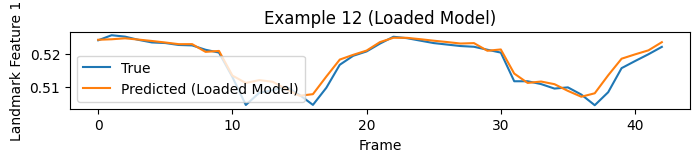

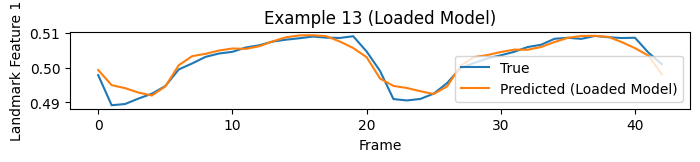

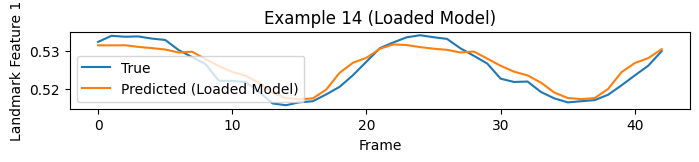

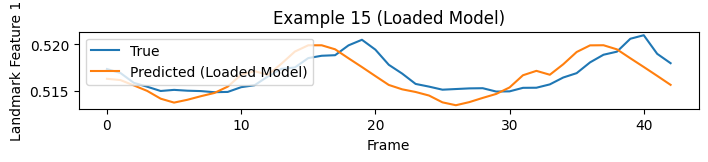

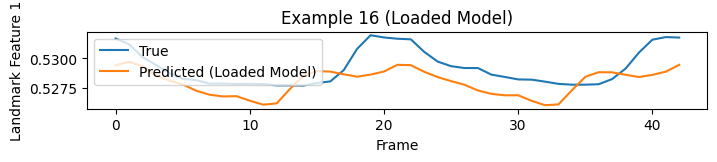

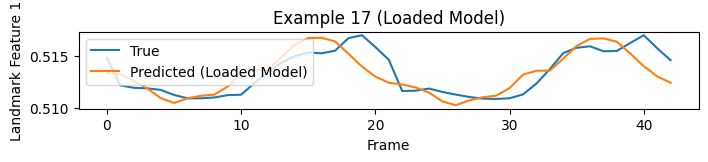

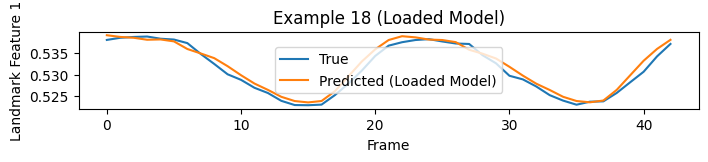

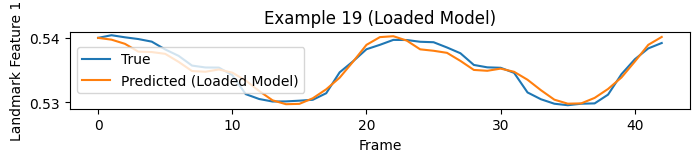

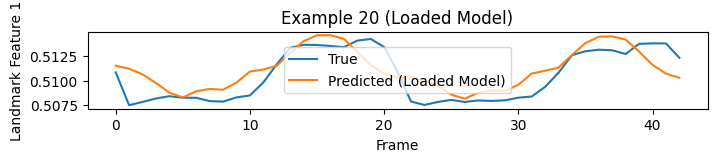

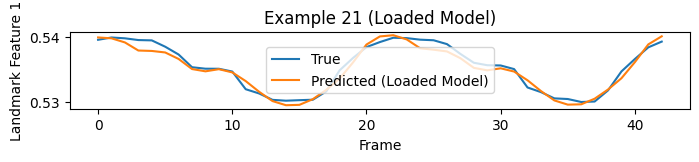

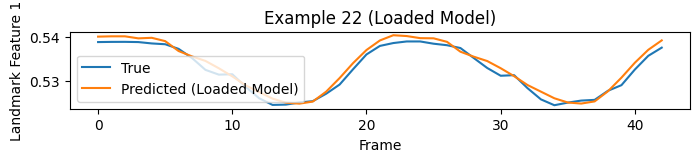

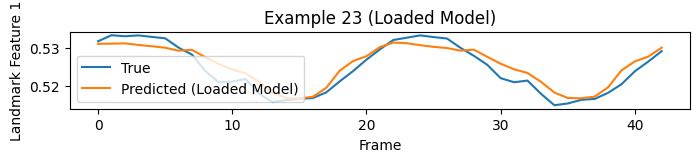

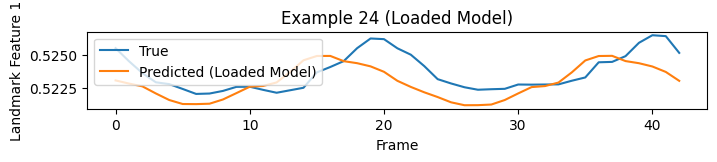

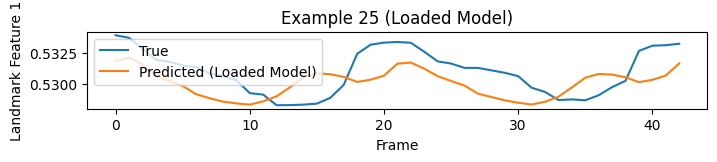

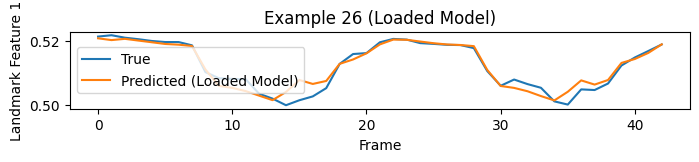

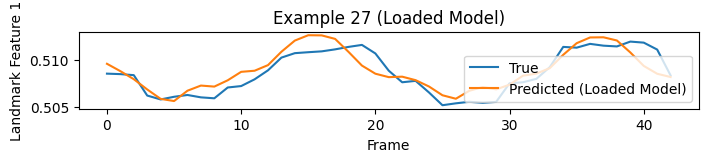

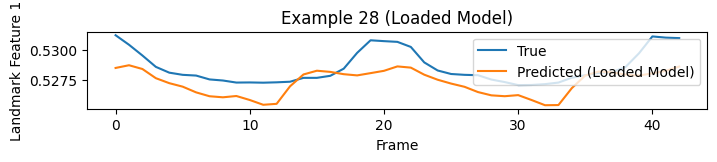

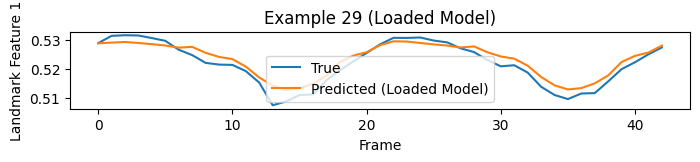

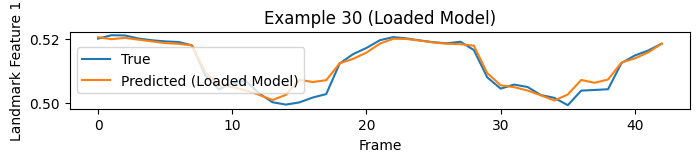

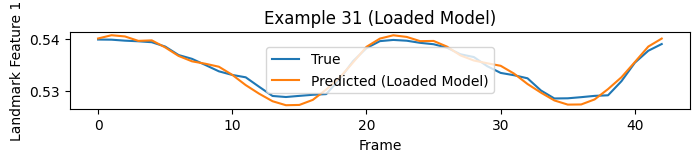

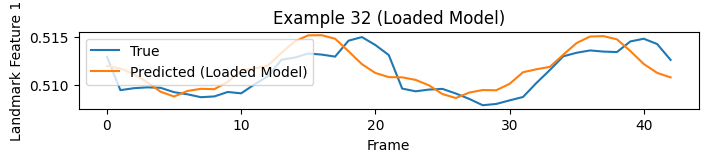

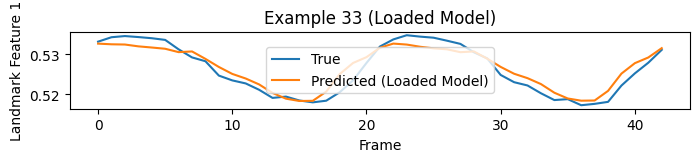

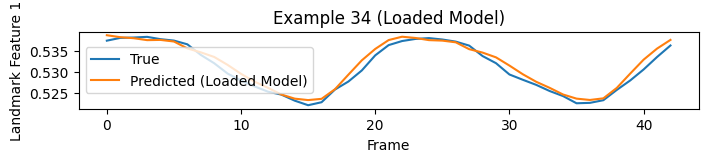

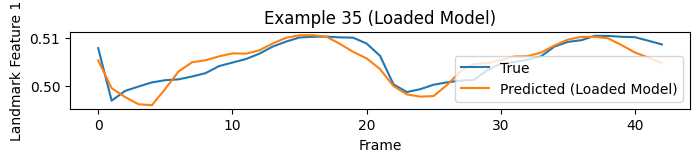

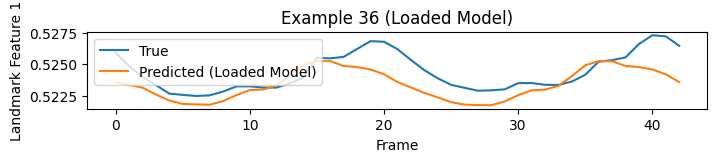

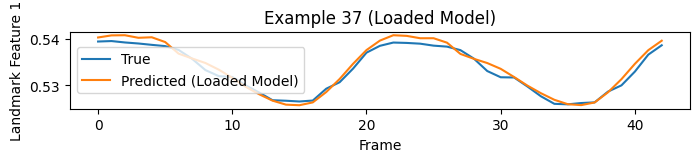

In [40]:
# 위에서 생성한 조건과 landmark를 모델에 입력하여 조건(각도)과 landmark관계를 학습하고 새로운 landmark를 생성하는 예
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint


# Batch Progress Logger Callback
class BatchProgressLogger(Callback):
    def on_train_batch_end(self, batch, logs=None):
        print(f"Batch {batch + 1} - Loss: {logs['loss']:.4f} - MAE: {logs.get('mae', 0):.4f}")

# 데이터 로드 함수
def load_data(condition_file, landmarks_dir):
    # 조건 데이터 로드
    condition_df = pd.read_csv(condition_file)
    conditions = condition_df["deg"].values  # Armature 회전값
    filenames = condition_df["fname"].values  # 관련된 Landmark 파일명

    # Landmark 데이터 로드
    landmark_data = []
    for fname in filenames:
        file_path = os.path.join(landmarks_dir, fname)
        df = pd.read_csv(file_path)
        df = df.loc[:, ~df.columns.str.contains('_z')]  # z컬럼 제거(각 관절의 x, y 좌표만 남김)
        landmark_data.append(df.values)  # CSV 데이터를 NumPy 배열로 저장

    return np.array(conditions), np.array(landmark_data)

# 데이터 경로
condition_file = "C:/test/anim_run_conditions.csv"      # 조건(각도)이 저장된 파일
landmarks_dir = "C:/test/landmarks-csv/run/"            # 학습할 Label 데이터가 저장된 디렉토리

# 데이터 로드
conditions, landmark_data = load_data(condition_file, landmarks_dir)

# 데이터 확인
print("조건 데이터 크기:", conditions.shape)  # (181,)
print("Landmark 데이터 크기:", landmark_data.shape)  # (181, 59, 24)

# 데이터 전처리
# 조건 데이터를 2D 배열로 변환
conditions = conditions.reshape(-1, 1)  # (181, 1)

# Train-Test 분할
X_train_cond, X_test_cond, Y_train, Y_test = train_test_split(
    conditions, landmark_data, test_size=0.2, random_state=42
)

# 모델 정의
def build_model(input_dim_condition, input_dim_landmark, seq_length):
    # Condition Input 
    condition_input = Input(shape=(1,), name="condition_input")
    condition_repeated = tf.expand_dims(condition_input, axis=-1)         # (batch, 1, 1)
    condition_repeated = tf.tile(condition_repeated, [1, seq_length, 1])  # (batch, seq_length, 1)

    # Landmark Input
    landmark_input = Input(shape=(seq_length, input_dim_landmark), name="landmark_input")

    # Concatenate Condition with Landmark Input
    combined_input = Concatenate(axis=-1, name="concatenate")([condition_repeated, landmark_input])

    # LSTM Layers
    initializer = tf.keras.initializers.GlorotUniform()
    lstm_output = LSTM(128, return_sequences=True, name="lstm", kernel_initializer="glorot_uniform")(combined_input)
    lstm_output = Dropout(0.2, name="dropout")(lstm_output)
    # LSTM 레이어를 한개 더 추가하면 더 부드러운 시각화 곡선이 확인됨
    lstm_output = LSTM(64, return_sequences=True, name="lstm2", kernel_initializer="glorot_uniform")(lstm_output)
    lstm_output = Dropout(0.2, name="dropout2")(lstm_output)
    dense_output = Dense(input_dim_landmark, activation="linear", name="dense")(lstm_output)

    # Model
    model = Model(inputs=[condition_input, landmark_input], outputs=dense_output)
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

# 모델 생성
input_dim_condition = 1                   # Condition의 피처 수
input_dim_landmark = 24                   # Landmark 데이터의 피처 수
seq_length = landmark_data.shape[1]       # Sequence 길이

model = build_model(input_dim_condition, input_dim_landmark, seq_length)

# 모델 요약
model.summary()

# EarlyStopping Callback
early_stop = EarlyStopping(
    monitor="val_loss",        # Validation Loss 기준
    patience=100,              # 100 epoch 동안 개선되지 않으면 학습 중단
    restore_best_weights=True  # 가장 낮은 Validation Loss에서의 가중치 복원
)

# ModelCheckpoint Callback
model_checkpoint = ModelCheckpoint(
    "c:/test/models/best_run_model.keras",  # 모델을 저장할 파일명
    monitor="val_loss",                 # Validation Loss 기준
    mode="min",
    save_best_only=True,                # 가장 좋은 모델만 저장
    verbose=0
)

#for i in range(0, 50):   # seed 값에 따라 학습 정도의 차이 확인
set_seed(43) 

model = build_model(input_dim_condition, input_dim_landmark, seq_length)

# 모델 학습
history = model.fit(
    [X_train_cond, Y_train], Y_train,
    validation_data=([X_test_cond, Y_test], Y_test),
    epochs=1000,
    batch_size=2,
    verbose=1,
    callbacks=[early_stop, model_checkpoint]
    #callbacks=[early_stop, model_checkpoint, BatchProgressLogger()]
)
loss, mae = model.evaluate(
    [X_test_cond, Y_test],  # 입력 데이터
    Y_test,                 # 출력 데이터 (라벨)
    batch_size=2,           # 배치 크기 (fit과 동일하게 설정)
    verbose=0               # 진행 상태 출력 (0 = 출력 없음, 1 = 진행 막대 출력)
)
# 평가 결과 출력
#print('seed=', i, f"Loss: {loss}, MAE: {mae}")


# 학습 내역 시각화
plt.figure(figsize=(5, 3))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 학습된 모델 저장(ModelCheckPoint 가 가장 좋은 모델을 자동으로 저장하므로 굳이 아래처럼 명시적으로 모델을 저장할 필요는 없음)
model_path = "c:/test/models/conditional_run_LSTM_model.keras"
model.save(model_path)
print(f"최종 학습된 모델이 {model_path}에 저장되었습니다.")

# 추론
predictions = model.predict([X_test_cond, Y_test])

# 결과 비교 (예제)
for i in range(3):  # 첫 3개의 예제를 시각화
    plt.figure(figsize=(8, 2))
    plt.plot(Y_test[i, :, 0], label='True')            # 검증용 레이블(개)
    plt.plot(predictions[i, :, 0], label='Predicted')  # 생성된 데이터(개)
    plt.title(f"Example {i+1}")
    plt.xlabel("Frame")
    plt.ylabel("Landmark Feature 1")
    plt.legend()
    plt.show()

# 저장된 모델 로드 및 추론
loaded_model = load_model(model_path)
print("저장된 모델을 성공적으로 로드했습니다.")

# 로드된 모델로 추론
loaded_predictions = loaded_model.predict([X_test_cond, Y_test])

# 로드된 모델 결과 비교
for i in range(3):
    plt.figure(figsize=(8, 2))
    plt.plot(Y_test[i, :, 0], label='True')
    plt.plot(loaded_predictions[i, :, 0], label='Predicted (Loaded Model)')
    plt.title(f"Example {i+1} (Loaded Model)")
    plt.xlabel("Frame")
    plt.ylabel("Landmark Feature 1")
    plt.legend()
    plt.show()


# 저장된 모델 로드 및 추론
loaded_model = load_model(model_path)
print("저장된 모델을 성공적으로 로드했습니다.")

# 로드된 모델로 추론
loaded_predictions = loaded_model.predict([X_test_cond, Y_test])

# 로드된 모델 결과 비교
for i in range(len(Y_test)):  # 생성된 각 Landmark를 순회
    plt.figure(figsize=(8, 1))
    plt.plot(Y_test[i, :, 0], label='True')
    plt.plot(loaded_predictions[i, :, 0], label='Predicted (Loaded Model)')
    plt.title(f"Example {i+1} (Loaded Model)")
    plt.xlabel("Frame")
    plt.ylabel("Landmark Feature 1")
    plt.legend()
    plt.show()

In [174]:
loaded_predictions = loaded_model.predict([X_test_cond, Y_test])
loaded_predictions.shape  # (12, 59, 24)
X_test_cond.shape         # (12, 1)
Y_test.shape              # (12, 59, 24)
Y_test[i, :, 0].shape     # (59,)

2/2 [==============================] - 0s 10ms/step


(43,)

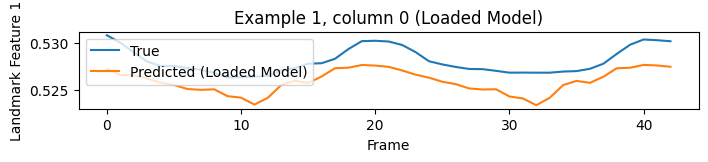

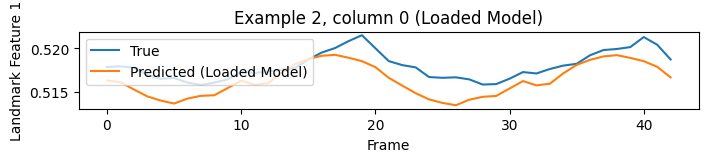

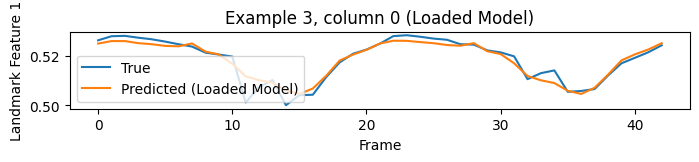

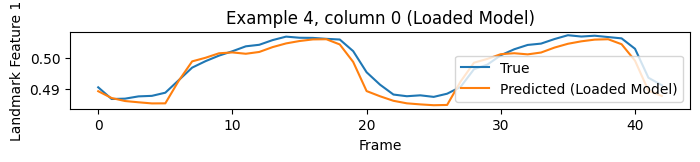

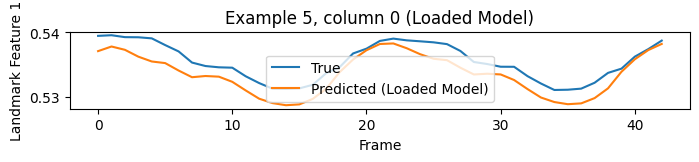

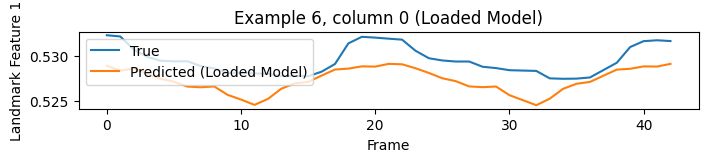

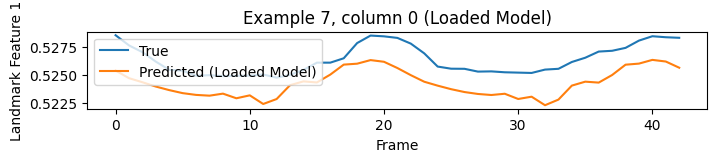

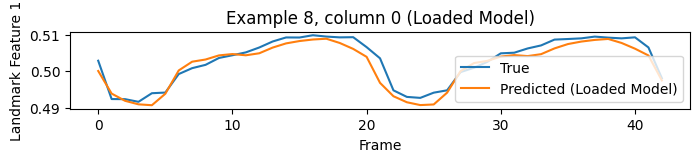

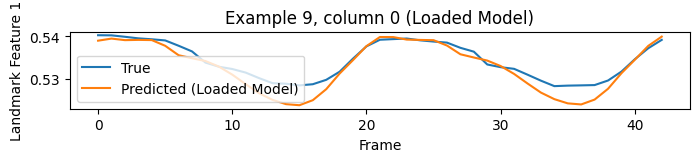

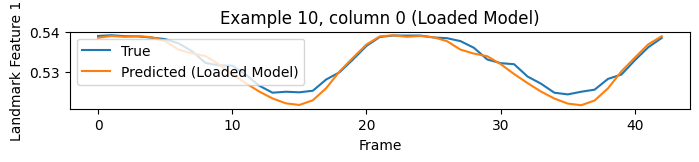

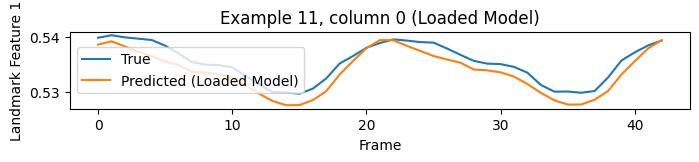

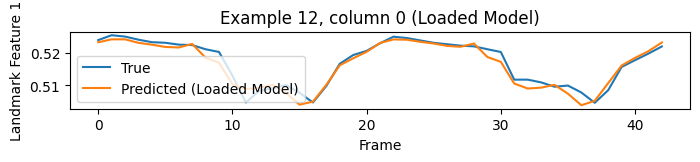

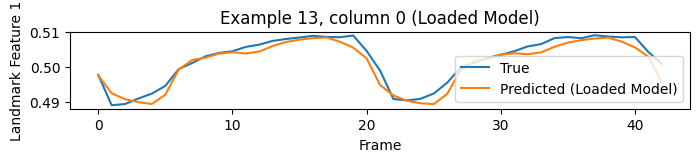

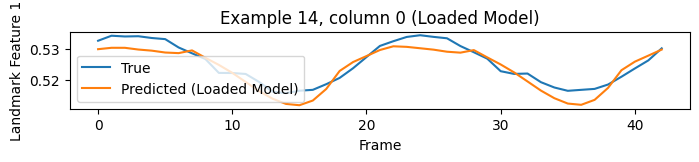

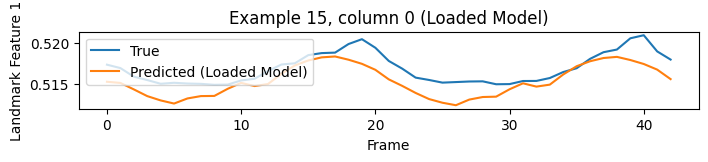

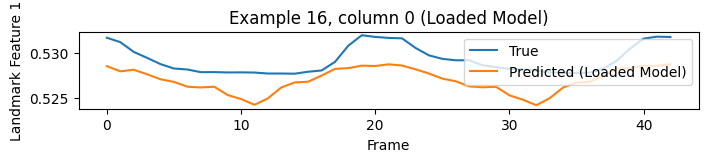

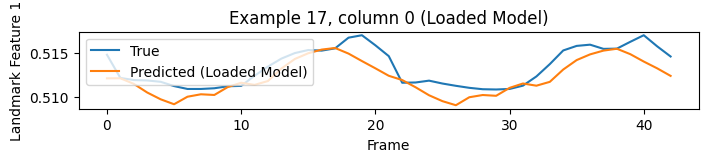

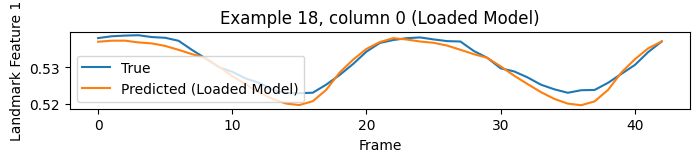

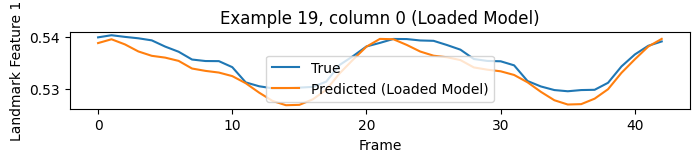

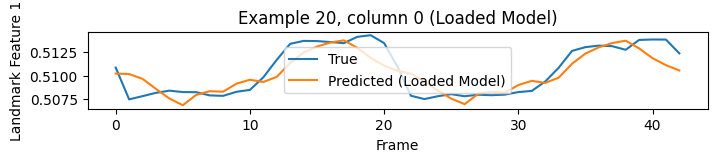

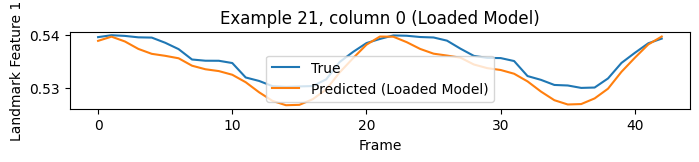

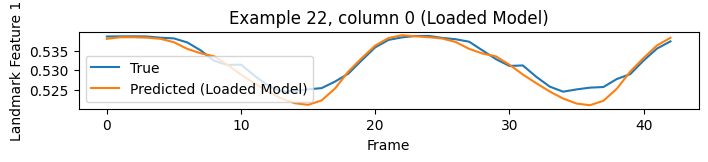

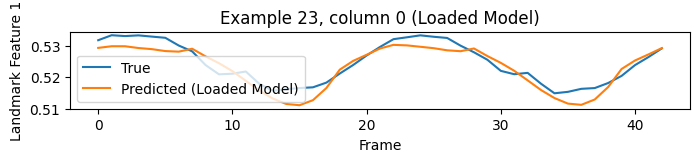

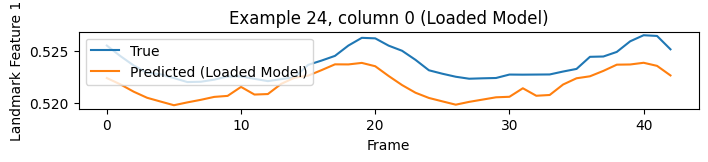

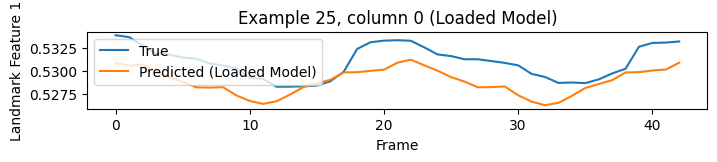

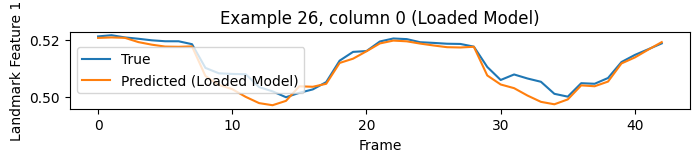

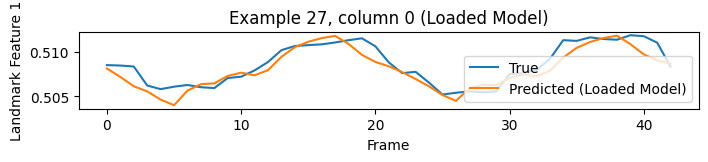

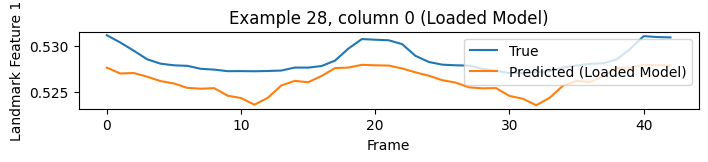

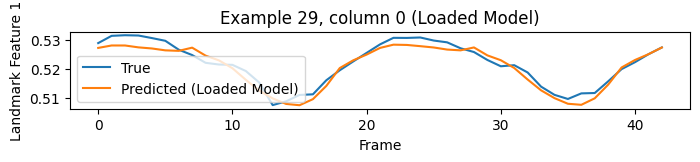

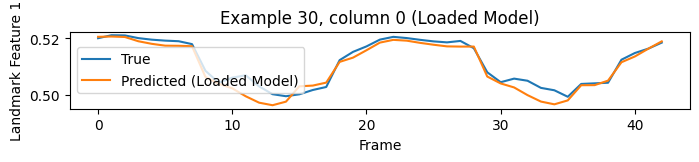

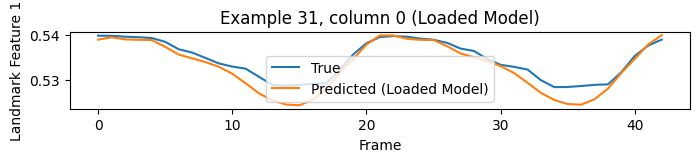

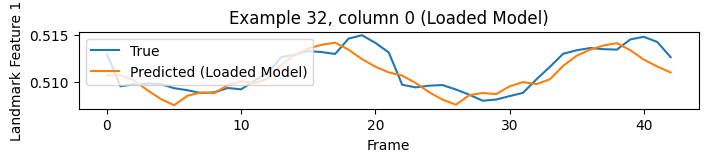

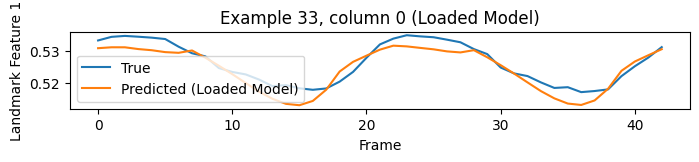

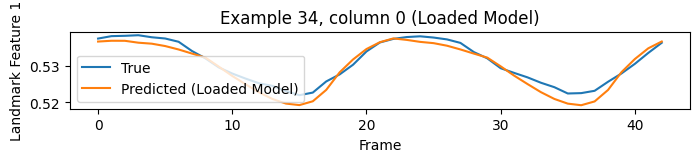

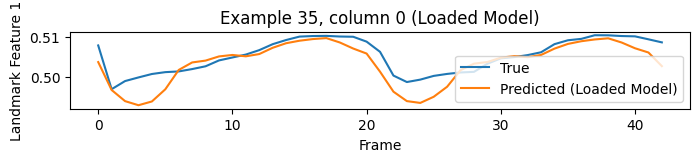

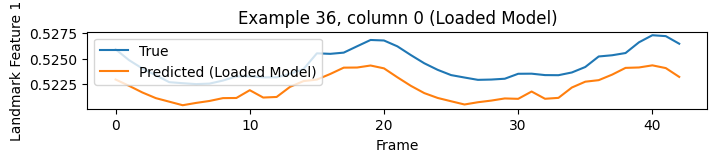

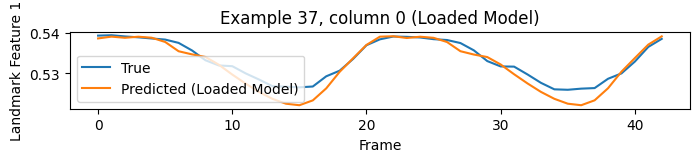

In [6]:
# 생성된 각 Landmark의 첫번째 컬럼값 비교
col = 0
for i in range(len(Y_test)):
    plt.figure(figsize=(8, 1))
    plt.plot(Y_test[i, :, col], label='True')
    plt.plot(loaded_predictions[i, :, col], label='Predicted (Loaded Model)')
    plt.title(f"Example {i+1}, column {col} (Loaded Model)")
    plt.xlabel("Frame")
    plt.ylabel("Landmark Feature 1")
    plt.legend()
    plt.show()

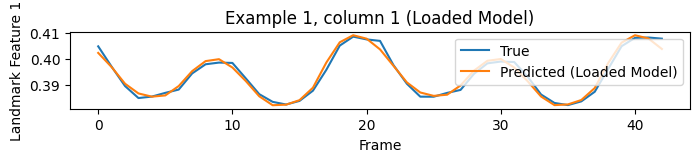

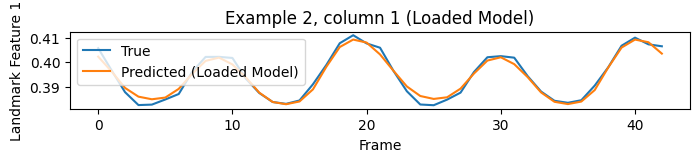

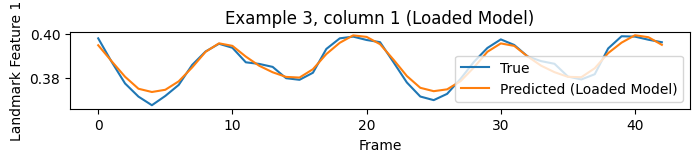

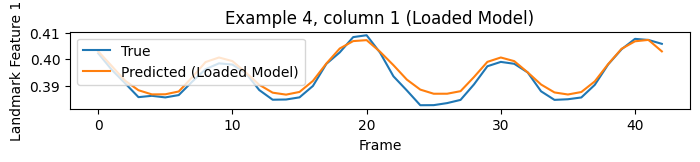

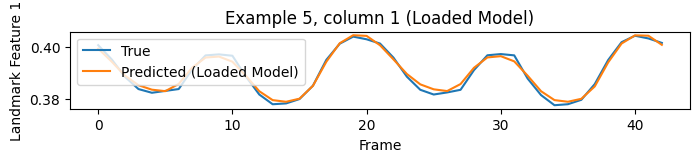

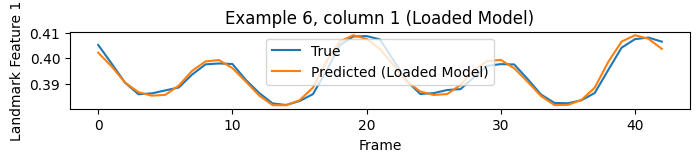

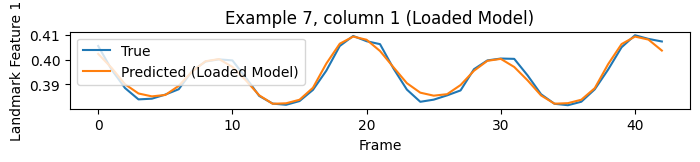

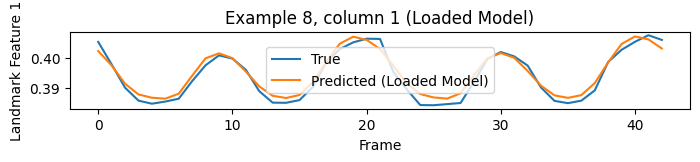

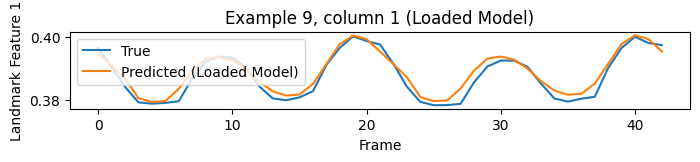

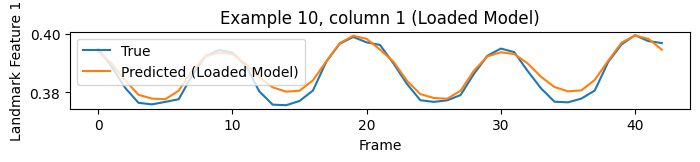

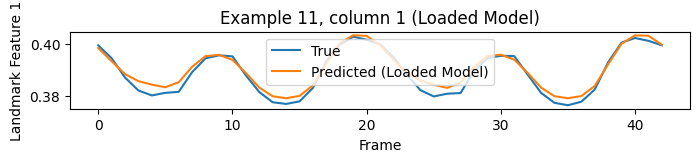

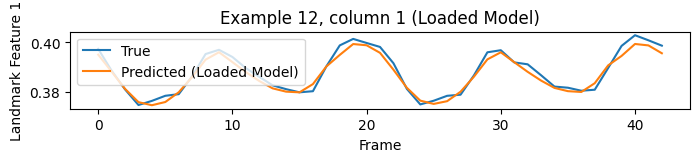

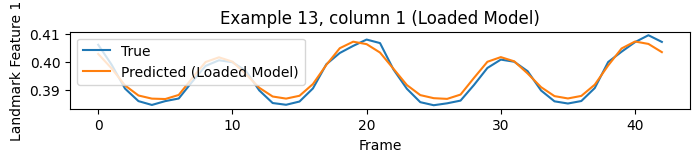

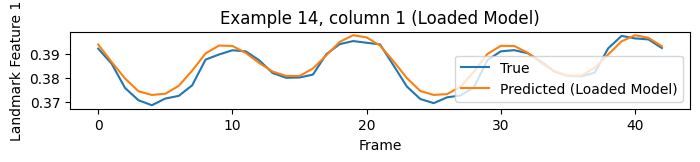

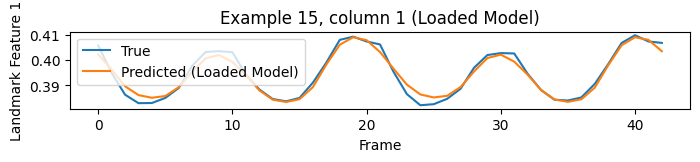

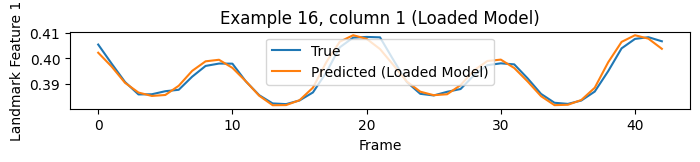

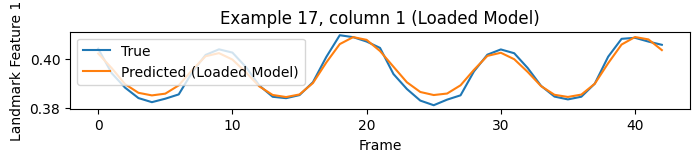

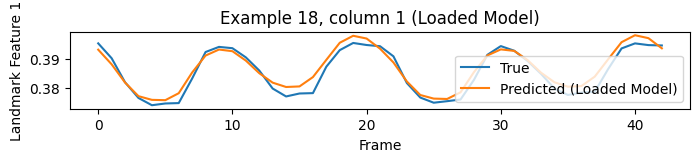

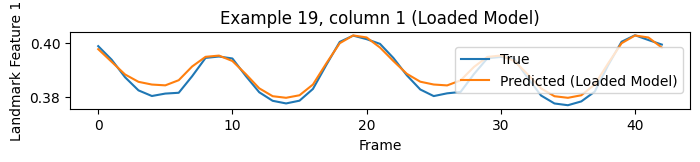

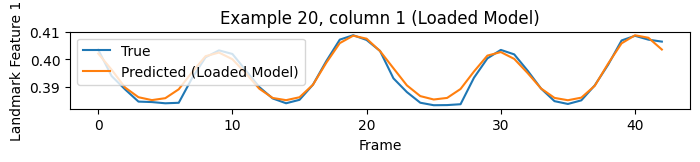

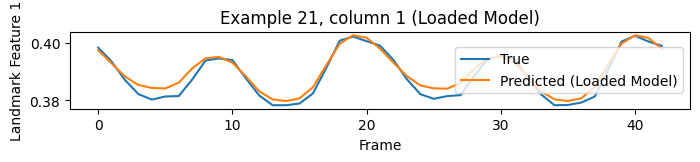

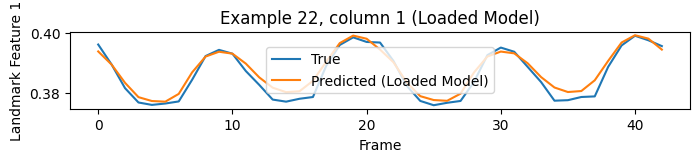

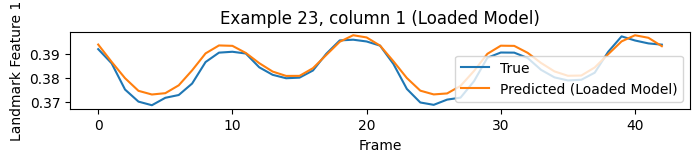

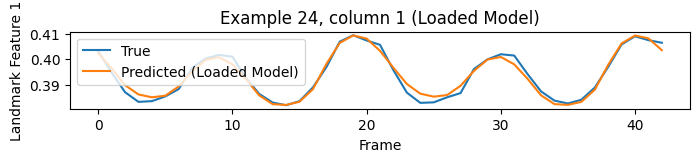

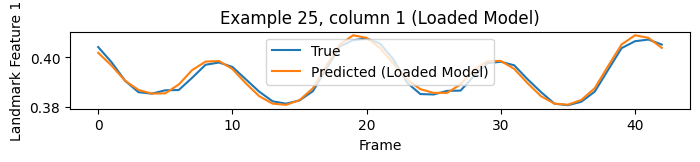

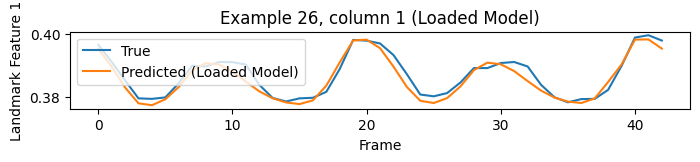

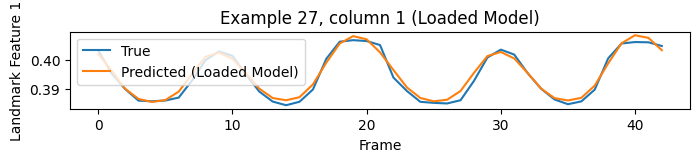

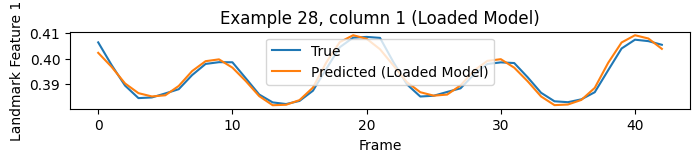

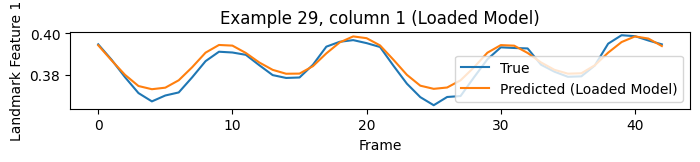

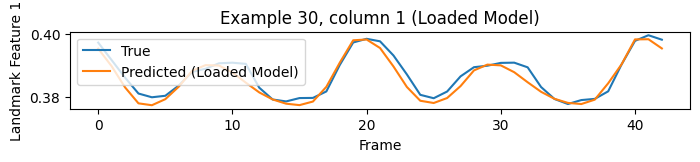

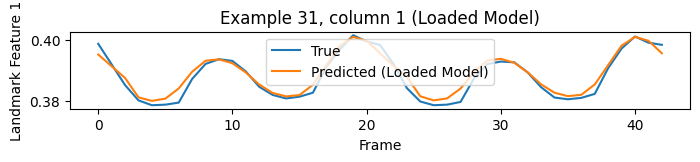

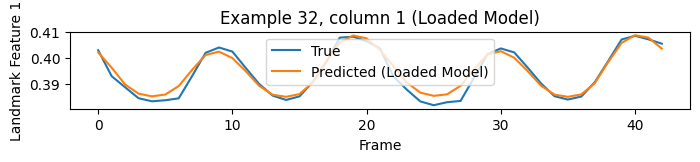

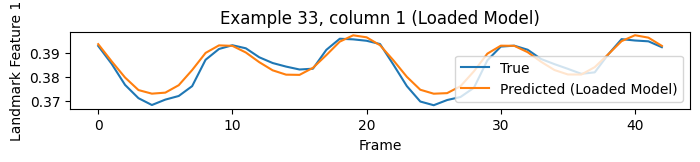

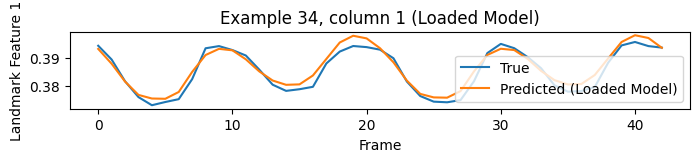

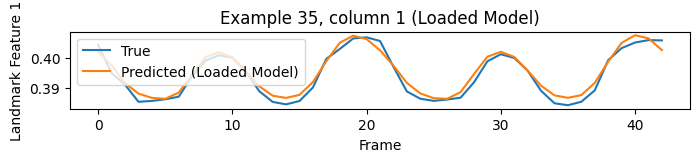

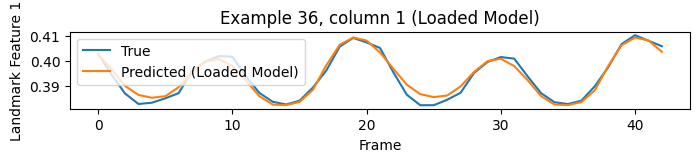

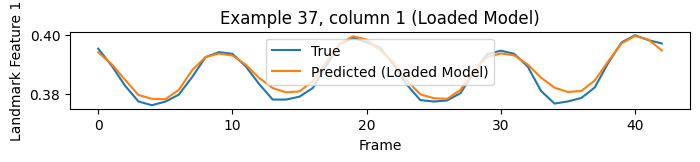

In [7]:
# 생성된 각 Landmark의 2번째 컬럼값 비교
col = 1
for i in range(len(Y_test)):
    plt.figure(figsize=(8, 1))
    plt.plot(Y_test[i, :, col], label='True')
    plt.plot(loaded_predictions[i, :, col], label='Predicted (Loaded Model)')
    plt.title(f"Example {i+1}, column {col} (Loaded Model)")
    plt.xlabel("Frame")
    plt.ylabel("Landmark Feature 1")
    plt.legend()
    plt.show()

## 학습된 모델을 사용하여 Landmark를 생성

In [27]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Model, load_model

### 저장된 best 걷기 모델 로드 및 사용

In [29]:
# 저장된 best 걷기 모델 로드 및 추론
model_path = model_path = "c:/test/models/best_walk_model.keras"
loaded_model = load_model(model_path)
print("저장된 걷기용 모델을 성공적으로 로드했습니다.")

저장된 걷기용 모델을 성공적으로 로드했습니다.


In [30]:
# 모델에 입력할 조건 지정
deg_cond = np.array(list(range(0, 91, 5)) + list(range(0, -91, -5))).reshape(-1, 1)
deg_cond.shape

(38, 1)

In [31]:
# Y dummy data (38, 43, 24)   # 걷기는 (59, 24), 달리기는 (43, 24)
Y_dummy = np.zeros((38, 59, 24))

In [32]:
loaded_predictions = loaded_model.predict([deg_cond, Y_dummy])

2/2 [==============================] - 0s 30ms/step


In [33]:
loaded_predictions.shape

(38, 59, 24)

In [34]:
loaded_predictions[0]

array([[0.5380967 , 0.3844671 , 0.46993136, ..., 0.6976869 , 0.49098673,
        0.68216527],
       [0.5452613 , 0.38213325, 0.46431148, ..., 0.7029065 , 0.485261  ,
        0.67843026],
       [0.5461758 , 0.3814481 , 0.46362263, ..., 0.70250624, 0.480333  ,
        0.6818667 ],
       ...,
       [0.53666914, 0.38877088, 0.47163653, ..., 0.6831137 , 0.499531  ,
        0.702488  ],
       [0.5367378 , 0.3893459 , 0.47148433, ..., 0.6774715 , 0.50270224,
        0.70492834],
       [0.5367231 , 0.38978457, 0.4713675 , ..., 0.67289114, 0.5046746 ,
        0.70623994]], dtype=float32)

In [35]:
# 저장할 때 사용할 컬럼명 준비(걷기/달리기 공통)
columns = pd.read_csv('C:/test/landmarks-csv/walk/animation_angle_0_qw_0.707_qx_0.707_qy_0.000_qz_0.000_dist_7.548.csv').columns
columns = [c for c in columns if not '_z' in c]

In [36]:
# 생성된 걷기 데이터를 csv 파일에 저장
for i, landmark in enumerate(loaded_predictions):
    pd.DataFrame(landmark, columns=columns).to_csv('C:/test/generated/walk/walk_deg_' + str(deg_cond[i,0]) +'.csv', index=False)
print('생성된 걷기 Landmark를 파일에 저장함')

생성된 걷기 Landmark를 파일에 저장함


### 저장된 달리기 best 모델 로드 및 사용

In [41]:
# 저장된 달리기 모델 로드 및 추론
model_path = model_path = "c:/test/models/best_run_model.keras"
loaded_model = load_model(model_path)
print("저장된 달리기 모델을 성공적으로 로드했습니다.")

저장된 달리기 모델을 성공적으로 로드했습니다.


In [42]:
# 모델에 입력할 조건 지정
deg_cond = np.array(list(range(0, 91, 5)) + list(range(0, -91, -5))).reshape(-1, 1)
deg_cond.shape

(38, 1)

In [43]:
loaded_predictions = loaded_model.predict([deg_cond, np.zeros((38, 43, 24))])
loaded_predictions.shape

2/2 [==============================] - 1s 25ms/step


(38, 43, 24)

In [44]:
# 저장할 때 사용할 컬럼명 준비(걷기/달리기 공통)
columns = pd.read_csv('C:/test/landmarks-csv/walk/animation_angle_0_qw_0.707_qx_0.707_qy_0.000_qz_0.000_dist_7.548.csv').columns
columns = [c for c in columns if not '_z' in c]

In [45]:
for i, landmark in enumerate(loaded_predictions):
    pd.DataFrame(landmark, columns=columns).to_csv('C:/test/generated/run/run_deg_' + str(deg_cond[i,0]) +'.csv', index=False)
print('생성된 달리기 Landmark를 파일에 저장함')

생성된 달리기 Landmark를 파일에 저장함
